In [24]:
import pandas as pd
import json
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import os

In [2]:
df = pd.read_csv('../../data/test-final/master_dataset_for_training.csv')

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Shape: (301, 31)

Columns:
 ['transcript_id', 'jd_id', 'candidate_id', 'segments', 'overall_scores.technical_skills', 'overall_scores.experience', 'overall_scores.problem_solving', 'overall_scores.communication', 'overall_scores.cultural_fit', 'Overall_Score', 'overall_scores.explanation', 'role', 'jd_text', 'extracted_skills', 'Questionnaire_ID', 'Transcript_ID', 'Role', 'Overall_Suitability', 'Interviewer_Comments', 'Ratings.Technical_Proficiency', 'Ratings.Problem_Solving_Ability', 'Ratings.Communication_Skills', 'Ratings.Cultural_Team_Fit', 'Ratings.Adaptability_Learning', 'segment_count', 'transcript_embedding', 'skills_vector', 'rec_Consider', 'rec_Hire', 'rec_Reject', 'structured_features']

Data types:
 transcript_id                       object
jd_id                               object
candidate_id                        object
segments                            object
overall_scores.technical_skills    float64
overall_scores.experience          float64
overall_scores.proble

In [4]:
print("\nFirst 10 rows:")
display(df.head(10))



First 10 rows:


,transcript_id,jd_id,candidate_id,segments,overall_scores.technical_skills,overall_scores.experience,overall_scores.problem_solving,overall_scores.communication,overall_scores.cultural_fit,Overall_Score,...,Ratings.Communication_Skills,Ratings.Cultural_Team_Fit,Ratings.Adaptability_Learning,segment_count,transcript_embedding,skills_vector,rec_Consider,rec_Hire,rec_Reject,structured_features
0,t001,ds_jd_01,c001,"[{""segment_id"": ""t001_a01"", ""speaker"": ""Candid...",0.95,0.92,0.90,0.94,0.93,0.93,...,1.00,1.00,1.00,NaN,"[-0.01575796357294339, -0.01892936692332188, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...
1,t002,ds_jd_01,c002,"[{""segment_id"": ""t002_a01"", ""speaker"": ""Candid...",0.92,0.88,0.90,0.85,0.89,0.89,...,1.00,0.75,1.00,NaN,"[-0.003749942939705951, -0.01209289917532156, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 0.75 1. 0. 1. 0. 0. ...
2,t003,ds_jd_01,c003,"[{""segment_id"": ""t003_a01"", ""speaker"": ""Candid...",0.75,0.70,0.78,0.80,0.72,0.75,...,0.75,0.75,0.75,NaN,"[-0.025586010115566844, -0.001228203945624485,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",True,False,False,[0.75 0.75 0.75 0.75 0.75 1. 0. 0. 0. ...
3,t004,ds_jd_01,c004,"[{""segment_id"": ""t004_a01"", ""speaker"": ""Candid...",0.95,0.95,0.90,0.95,0.90,0.93,...,1.00,1.00,1.00,NaN,"[-0.02135167594809402, 0.0038519784337327687, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...
4,t005,ds_jd_01,c005,"[{""segment_id"": ""t005_a01"", ""speaker"": ""Candid...",0.92,0.91,0.89,0.88,0.90,0.90,...,1.00,1.00,1.00,NaN,"[-0.01619285595759264, -0.004747431692865577, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...
5,t006,ds_jd_01,c006,"[{""segment_id"": ""t006_a01"", ""speaker"": ""Candid...",0.85,0.83,0.82,0.80,0.79,0.82,...,1.00,1.00,1.00,NaN,"[0.0003718015403234619, -0.012810620518060038,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...
6,t007,ds_jd_01,c007,"[{""segment_id"": ""t007_a01"", ""speaker"": ""Candid...",0.70,0.65,0.72,0.82,0.90,0.76,...,0.75,1.00,0.75,NaN,"[-0.0134995663953265, 0.0018679311058180299, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",True,False,False,[0.75 0.75 0.75 1. 0.75 1. 0. 0. 0. ...
7,t008,ds_jd_01,c008,"[{""segment_id"": ""t008_a01"", ""speaker"": ""Candid...",0.95,0.90,0.95,0.90,0.95,0.93,...,1.00,0.75,1.00,NaN,"[-0.03163037717217497, 0.0002216270311934036, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 0.75 1. 0. 1. 0. 0. ...
8,t009,ds_jd_01,c009,"[{""segment_id"": ""t009_a01"", ""speaker"": ""Candid...",0.93,0.92,0.90,0.92,0.93,0.92,...,1.00,1.00,1.00,NaN,"[-0.034252480872903245, -0.011503044497631447,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...
9,t010,ds_jd_01,c010,"[{""segment_id"": ""t010_a01"", ""speaker"": ""Candid...",0.95,0.93,0.95,0.90,0.92,0.93,...,1.00,1.00,1.00,NaN,"[-0.012443813810083916, -0.018815759011361736,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",False,True,False,[1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. ...


In [5]:
numeric_cols = [
    'overall_scores.technical_skills',
    'overall_scores.experience',
    'overall_scores.problem_solving',
    'overall_scores.communication',
    'overall_scores.cultural_fit',
    'Overall_Score',
    'segment_count'
]
print("\nNumeric summary:")
print(df[numeric_cols].describe())


Numeric summary:
       overall_scores.technical_skills  overall_scores.experience  \
count                        301.00000                 301.000000   
mean                           0.99711                   0.953987   
std                            5.61477                   5.174457   
min                            0.15000                   0.100000   
25%                            0.40000                   0.400000   
50%                            0.70000                   0.700000   
75%                            0.90000                   0.900000   
max                           98.00000                  90.300000   

       overall_scores.problem_solving  overall_scores.communication  \
count                      301.000000                    301.000000   
mean                         0.671834                      0.716870   
std                          0.214660                      0.188568   
min                          0.200000                      0.300000   
25%  

In [7]:
#  Find transcripts with out‑of‑range scores
mask_ts = df['overall_scores.technical_skills'] > 1
mask_exp = df['overall_scores.experience'] > 1
print("Out‑of‑range technical_skills (>1):", df.loc[mask_ts, ['transcript_id','overall_scores.technical_skills']])
print("Out‑of‑range experience (>1):",    df.loc[mask_exp, ['transcript_id','overall_scores.experience']])


Out‑of‑range technical_skills (>1):    transcript_id  overall_scores.technical_skills
77          t078                             98.0
Out‑of‑range experience (>1):     transcript_id  overall_scores.experience
49           t050                        3.0
128          t129                       90.3


In [8]:
#Check segment_count dtype & parse it
print("\nsegment_count dtype before:", df['segment_count'].dtype)
df['segment_count'] = pd.to_numeric(df['segment_count'], errors='coerce')
print("segment_count summary after coercion:")
print(df['segment_count'].describe())


segment_count dtype before: float64
segment_count summary after coercion:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: segment_count, dtype: float64


In [9]:
offenders = ['t078', 't050', 't129']
print("\nRows with out‑of‑range scores:")
print(df.loc[df['transcript_id'].isin(offenders),
             ['transcript_id',
              'overall_scores.technical_skills',
              'overall_scores.experience',
              'overall_scores.problem_solving',
              'overall_scores.communication',
              'overall_scores.cultural_fit']])


Rows with out‑of‑range scores:
    transcript_id  overall_scores.technical_skills  overall_scores.experience  \
49           t050                             0.20                       3.00   
77           t078                            98.00                       0.96   
128          t129                             0.35                      90.30   

     overall_scores.problem_solving  overall_scores.communication  \
49                             0.35                          0.50   
77                             0.95                          0.97   
128                            0.35                          0.40   

     overall_scores.cultural_fit  
49                          0.50  
77                          0.94  
128                         0.40  


In [12]:
# 2. Recompute segment_count from the JSON in `segments`
def count_segs(seg_str):
    try:
        return len(json.loads(seg_str))
    except:
        return None

df['segment_count'] = df['segments'].apply(count_segs)
print("\nRecomputed segment_count summary:")
print(df['segment_count'].describe())


Recomputed segment_count summary:
count    301.000000
mean      14.710963
std        3.594372
min        1.000000
25%       13.000000
50%       13.000000
75%       16.000000
max       26.000000
Name: segment_count, dtype: float64


In [13]:
# Clamp every overall_scores* field (and Overall_Score) to [0,1]
score_cols = [
    'overall_scores.technical_skills',
    'overall_scores.experience',
    'overall_scores.problem_solving',
    'overall_scores.communication',
    'overall_scores.cultural_fit',
    'Overall_Score'
]
for c in score_cols:
    df[c] = df[c].clip(lower=0.0, upper=1.0)

# Print updated summary
print("Updated numeric summary after clamping:")
print(df[score_cols].describe())

Updated numeric summary after clamping:
       overall_scores.technical_skills  overall_scores.experience  \
count                       301.000000                 301.000000   
mean                          0.674850                   0.650664   
std                           0.237158                   0.244376   
min                           0.150000                   0.100000   
25%                           0.400000                   0.400000   
50%                           0.700000                   0.700000   
75%                           0.900000                   0.900000   
max                           1.000000                   1.000000   

       overall_scores.problem_solving  overall_scores.communication  \
count                      301.000000                    301.000000   
mean                         0.671834                      0.716870   
std                          0.214660                      0.188568   
min                          0.200000                 

In [26]:
output_file = '../data/test-final/FINAL_master.csv'
df.to_csv(output_file, index=False)
print(f"Master dataset with structured features saved to '{output_file}'")

Master dataset with structured features saved to '../data/test-final/FINAL_master.csv'


## EDA

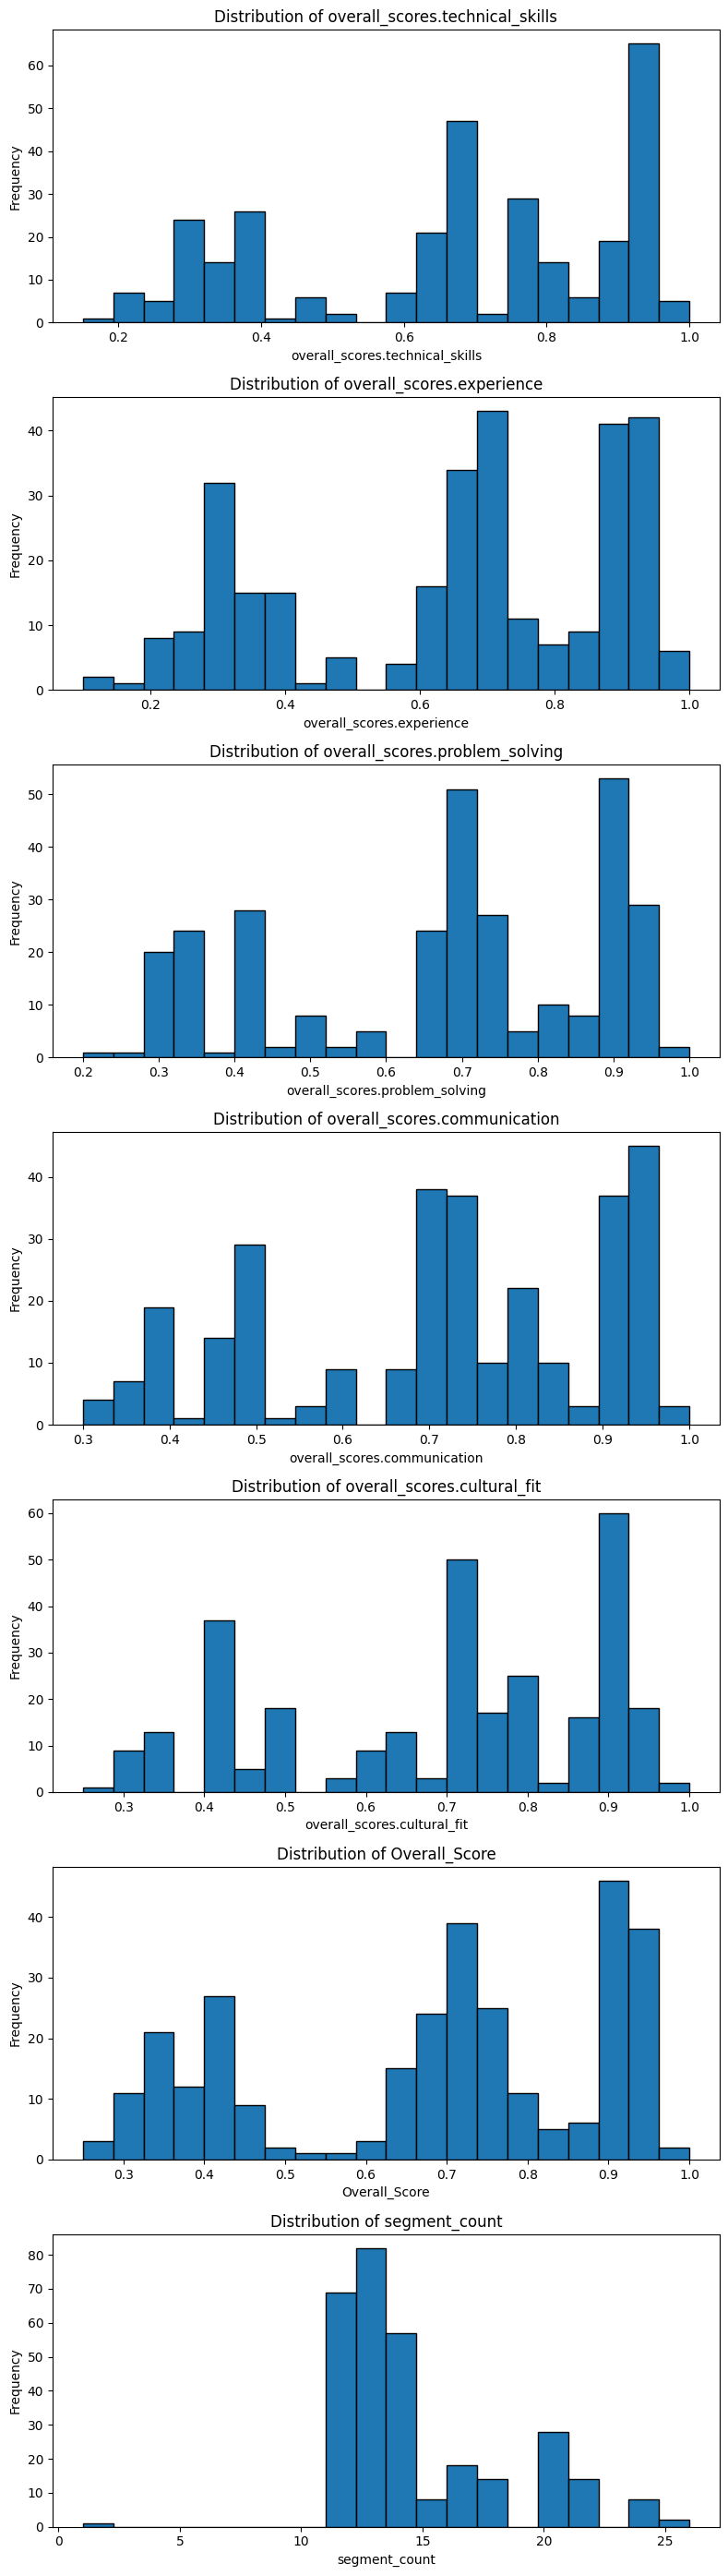

In [20]:
# --- 1. Histograms for numeric features ---
numeric_cols = [
    'overall_scores.technical_skills',
    'overall_scores.experience',
    'overall_scores.problem_solving',
    'overall_scores.communication',
    'overall_scores.cultural_fit',
    'Overall_Score',
    'segment_count'
]

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(8, 4 * len(numeric_cols)))
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=20, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

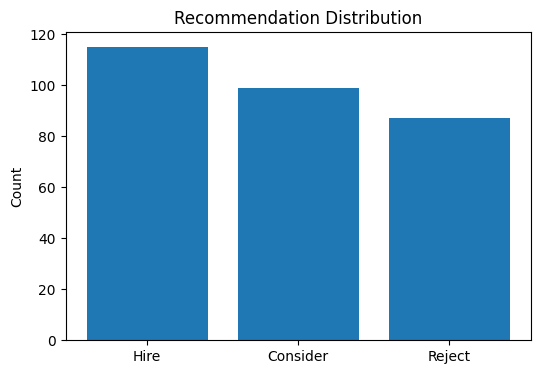

In [21]:
# --- 2. Recommendation Distribution ---
rec_cols = ['rec_Hire', 'rec_Consider', 'rec_Reject']
rec_counts = df[rec_cols].sum()
plt.figure(figsize=(6,4))
plt.bar(['Hire','Consider','Reject'], rec_counts.values)
plt.title('Recommendation Distribution')
plt.ylabel('Count')
plt.show()


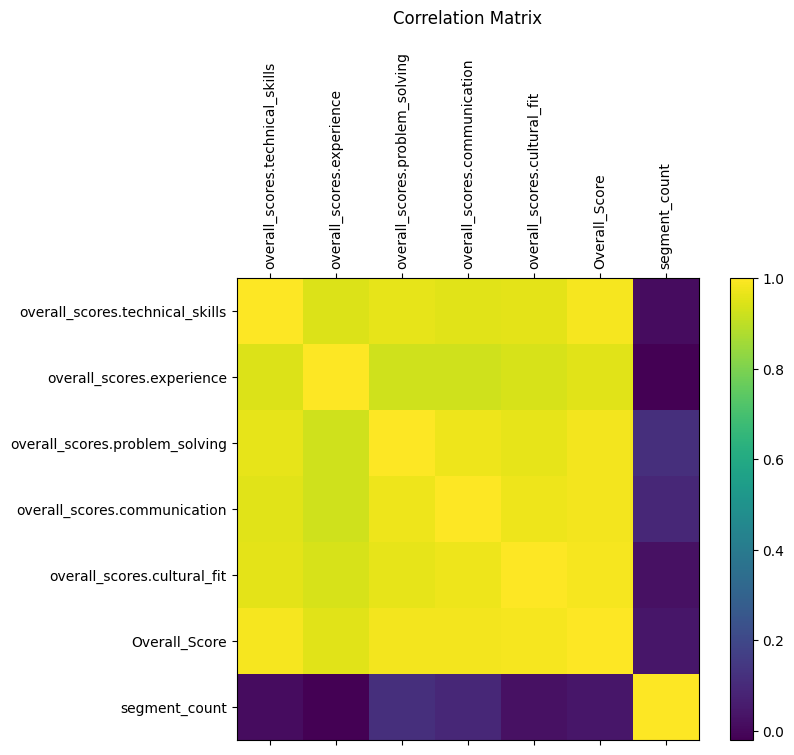

In [22]:
# --- 3. Correlation Matrix Heatmap ---
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(corr, cmap='viridis')
fig.colorbar(cax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)
plt.title('Correlation Matrix', pad=20)
plt.show()

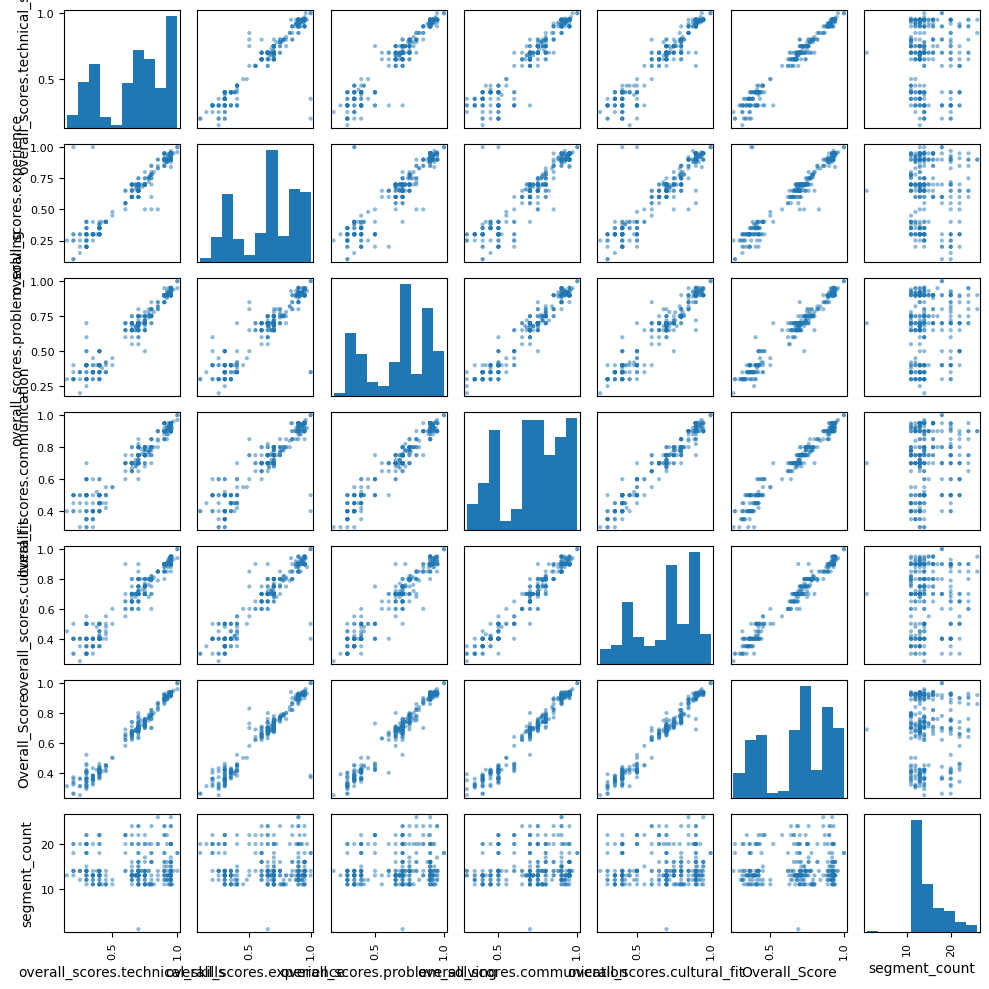

In [23]:
# --- 4. Scatter‑Matrix of Numeric Features ---
scatter_matrix(df[numeric_cols], figsize=(10, 10), diagonal='hist')
plt.tight_layout()
plt.show()

EDA - Observations

---

## 1. Score Distributions  
- **Bimodal peaks** around 0.3–0.5 and 0.7–1.0 for all five dimension‑scores and the overall suitability.  
  - This likely reflects two “groups” of interviews: weaker (mid‑range) vs. stronger (high range).  
- **No severe skew** or long tails—your clamping worked, and all scores sit neatly in \[0, 1\].  

## 2. Segment Count  
- Mostly clustered between **12–16 segments**, with a few interviews as short as 1 and as long as 26.  
- **Very weak correlation** (≈0) with any of the scores—so segment count probably isn’t a predictive feature in itself. You can leave it out of early baselines or use it later as an “auxiliary” feature.

## 3. Recommendations (“Hire/Consider/Reject”)  
- Fairly balanced:  
  - ~115 “Hire”  
  - ~99 “Consider”  
  - ~87 “Reject”  
- No severe class imbalance, so can train a 3‑class classifier

## 4. High Inter‑Feature Correlations  
- Almost all pairwise correlations among the five dimension‑scores and the overall score are **>0.8**, many approaching 0.95–0.99.  
  - That means these ratings are largely redundant.  
  - we can either,
    1. **Keep them all** and let a model learn the redundancy (tree‑based models handle this fine).  
    2. **Reduce dimensionality** (e.g. PCA or simply average the five scores into a single “mean rating” feature).
